<a href="https://colab.research.google.com/github/dherreraal/data_structures/blob/main/Clase_07/07_ED_Dynamic_Arrays.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Arreglos Dinámicos y Análisis Amortizado
### Universidad Nacional de Colombia
#### **Profesor:** David Alberto Herrera Alvarez  
#### **Curso:** Estructuras de Datos
---

## Índice de Contenido
1. Introducción: Arreglos Estáticos vs. Dinámicos
2. El Tipo de Dato Abstracto (ADT): Arreglo Dinámico
3. Detalles de Implementación Interna y Crecimiento Paso a Paso
4. Alternativas de Crecimiento: ¿Por qué duplicar el tamaño?
5. Análisis Amortizado de Inserciones (`PushBack`)
    - 5.1 Método Agregado (Aggregate Method)
    - 5.2 Método del Banquero (Banker's Method)
    - 5.3 Método del Físico (Physicist's Method)
6. Optimizaciones y Aplicaciones Avanzadas
    - 6.1 Aplicación: Pilas (Stacks) y Corchetes Balanceados
    - 6.2 Aplicación: Colas Circulares (Circular Queues)
    - 6.3 Shrinking: Recuperando Memoria Perdida
    - 6.4 ¿Qué pasa "Bajo el capó"? (Garbage Collection vs Realloc)
7. Batalla de Rendimiento: Arreglos Dinámicos vs. Listas Enlazadas
8. Ejercicios Prácticos
9. Resumen
10. Bibliografía
---

## 1. Introducción: Arreglos Estáticos vs. Dinámicos

El problema principal de los arreglos estáticos en memoria es que **son estáticos**. Su tamaño no puede cambiar una vez han sido creados.
```java
// Arreglo de tamaño fijo (100 elementos)
int[] miArreglo = new int[100];
```
Si almacenamos 100 elementos y queremos agregar uno más, no podemos simplemente "expandir" el arreglo porque el sistema operativo no garantiza que el espacio contiguo en memoria esté libre.

Como dice el famoso dicho:
> *Todos los problemas en ciencias de la computación pueden resolverse añadiendo un nivel de indirección.*

La solución son los **Arreglos Dinámicos (Dynamic Arrays)** o *Resizable Arrays*. La idea fundamental es guardar un puntero hacia un arreglo alojado dinámicamente en memoria, y **reemplazarlo** por un arreglo nuevo más grande cuando se llene.


## 2. El Tipo de Dato Abstracto (ADT): Arreglo Dinámico

Un arreglo dinámico es un Abstract Data Type (ADT) que provee, como mínimo, las siguientes operaciones:

*   **`Get(i)`**: Retorna el elemento en la posición `i`. (Debe ser tiempo constante $O(1)$)
*   **`Set(i, val)`**: Establece el elemento en la posición `i` con el valor `val`. (Debe ser tiempo constante $O(1)$)
*   **`PushBack(val)`**: Agrega el valor `val` al final del arreglo.
*   **`Remove(i)`**: Elimina el elemento en la posición `i`, desplazando los siguientes.
*   **`Size()`**: Retorna el número de elementos guardados actualmente.

### Implementaciones Comunes en la Industria
La mayoría de lenguajes de programación modernos incluyen arreglos dinámicos en su biblioteca estándar:
*   **Java:** `ArrayList`
*   **C++:** `std::vector`
*   **Python:** `list` (en Python, las listas son por debajo arreglos dinámicos, no listas enlazadas).


## 3. Detalles de Implementación Interna y Crecimiento Paso a Paso

Para implementar esta estructura de datos, internamente necesitamos guardar 3 cosas:
1.  **`arr`**: El arreglo alojado dinámicamente.
2.  **`capacity`**: El tamaño total de memoria que tiene el arreglo `arr` (cuánto le cabe en total).
3.  **`size`**: El número de elementos reales que el usuario ha insertado en el arreglo.

### La Operación `PushBack(val)`
La clave del arreglo dinámico ocurre al insertar al final. Observa la siguiente secuencia visual donde empezamos con un arreglo de Capacidad = 2 e insertamos las letras 'a', 'b', 'c', 'd', 'e'.

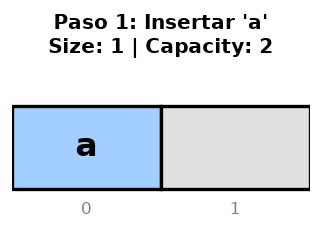

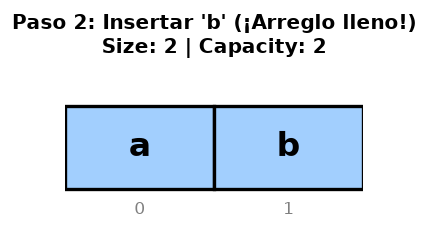

**¡Alerta!** Al intentar insertar 'c', el `size` es igual a la `capacity`. No hay espacio. La estructura internamente hace lo siguiente:
1. Aloja un nuevo arreglo de tamaño el doble de la capacidad actual ($2 \times 2 = 4$).
2. Copia 'a' y 'b' al nuevo arreglo.
3. Libera el arreglo viejo y hace que `arr` apunte al nuevo.
4. Inserta 'c'.

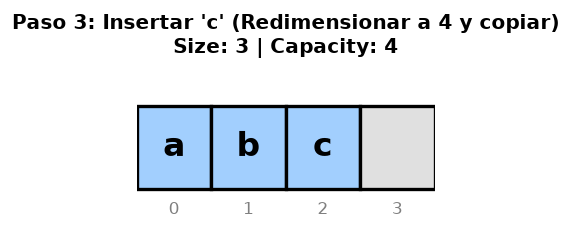

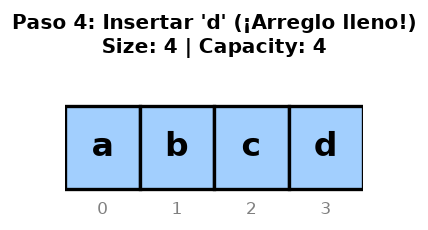

Nuevamente el arreglo está lleno. Al insertar 'e', se vuelve a duplicar la capacidad (de 4 pasa a 8), se copian los 4 elementos y se inserta 'e'.

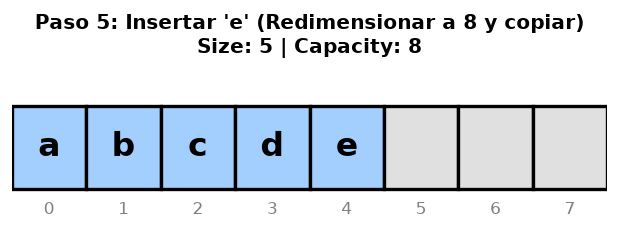

### Tiempos de Ejecución (Runtimes) en el Peor Caso
*   **`Get(i)`**: $O(1)$
*   **`Set(i, val)`**: $O(1)$
*   **`Size()`**: $O(1)$
*   **`PushBack(val)`**: $O(n)$ en el peor caso, porque si el arreglo está lleno, hay que copiar $n$ elementos al nuevo arreglo.
*   **`Remove(i)`**: $O(n)$ en el peor caso, porque hay que desplazar hacia la izquierda todos los elementos posteriores a `i`.


## 4. Alternativas de Crecimiento: ¿Por qué duplicar el tamaño?

¿Podríamos crecer el arreglo de otra forma? ¿Qué pasaría si en lugar de multiplicarlo por un factor (como `2` o `1.5`), decidimos expandirlo sumándole una **cantidad constante** (ej. sumar 10 espacios extra cada vez que se llena)?

Si expandimos en 10 cada vez:
El costo de la i-ésima inserción $c_i$ sería $1 + (i-1)$ cada vez que $(i-1)$ es un múltiplo de 10.
Matemáticamente, la suma de los costos para $n$ inserciones daría:
$$ \sum_{i=1}^{n} c_i = n + 10 \sum_{j=1}^{(n-1)/10} j $$
Esto resulta en un tiempo total de **$O(n^2)$** para insertar $n$ elementos, lo que significa que el tiempo promedio por inserción caería a **$O(n)$**, volviendo la estructura extremadamente ineficiente.

Por esto, **siempre debemos usar un factor multiplicativo** (duplicar el tamaño) para garantizar eficiencia.


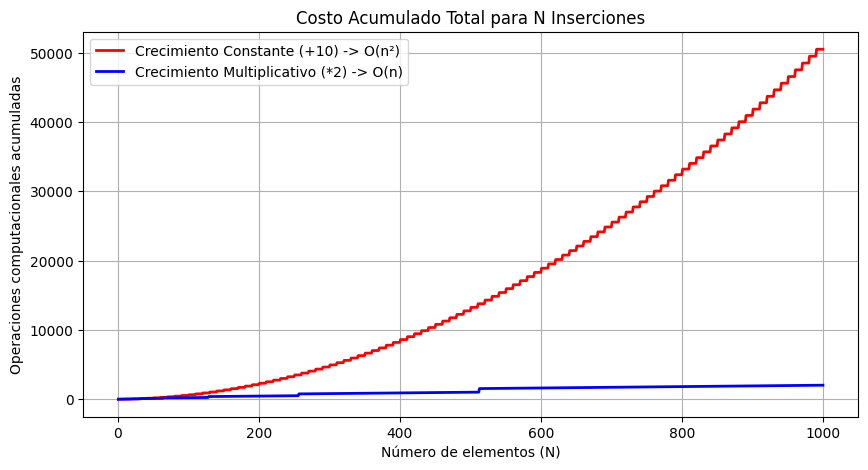

In [1]:
import matplotlib.pyplot as plt

# Simulación de inserciones
n_elements = 1000

# 1. Crecimiento por suma constante (+10)
cost_constant = []
total_cost_c = 0
capacity_c = 10
for i in range(1, n_elements + 1):
    if i > capacity_c:
        capacity_c += 10 # Crecimiento lineal
        total_cost_c += (i - 1) # Costo de copiar los anteriores
    total_cost_c += 1 # Costo de insertar el nuevo
    cost_constant.append(total_cost_c)

# 2. Crecimiento multiplicativo (*2)
cost_doubling = []
total_cost_d = 0
capacity_d = 1
for i in range(1, n_elements + 1):
    if i > capacity_d:
        capacity_d *= 2 # Crecimiento exponencial
        total_cost_d += (i - 1) # Costo de copiar los anteriores
    total_cost_d += 1 # Costo de insertar el nuevo
    cost_doubling.append(total_cost_d)

plt.figure(figsize=(10, 5))
plt.plot(range(1, n_elements + 1), cost_constant, label="Crecimiento Constante (+10) -> O(n²)", color="red", linewidth=2)
plt.plot(range(1, n_elements + 1), cost_doubling, label="Crecimiento Multiplicativo (*2) -> O(n)", color="blue", linewidth=2)
plt.title("Costo Acumulado Total para N Inserciones")
plt.xlabel("Número de elementos (N)")
plt.ylabel("Operaciones computacionales acumuladas")
plt.legend()
plt.grid(True)
plt.show()


## 5. Análisis Amortizado de Inserciones (`PushBack`)

A veces, analizar el peor caso individual (`PushBack` toma $O(n)$) es demasiado severo y pesimista. Sabemos que redimensionamos el arreglo *muy de vez en cuando*. Muchas inserciones de $O(1)$ son seguidas por una sola inserción pesada de $O(n)$.

Para estudiar el comportamiento global, usamos el **Costo Amortizado**:
> Dado un conjunto de $n$ operaciones, el costo amortizado es el Costo total de las $n$ operaciones dividido entre $n$.


### 5.1 Método Agregado (Aggregate Method)
Este método es una simple suma de fuerza bruta de todos los costos, divididos por $n$.

Si hacemos $n$ llamadas a `PushBack`, sea $c_i$ el costo de la inserción $i$:
$$ c_i = 1 + \begin{cases} i-1 & \text{si } i-1 \text{ es una potencia de 2} \\ 0 & \text{de otra forma} \end{cases} $$

Si sumamos todos los $c_i$ desde $1$ hasta $n$:
$$ \sum_{i=1}^{n} c_i = n + \sum_{j=1}^{\lfloor\log_2(n-1)\rfloor} 2^j $$
Como la sumatoria de potencias de 2 (hasta llegar a $n$) nunca es mayor a $2n$, el total de la suma es estrictamente menor a $3n$, lo cual es $\approx O(n)$.

Por lo tanto, si $n$ operaciones toman $O(n)$, el costo amortizado por operación es **$O(1)$**.


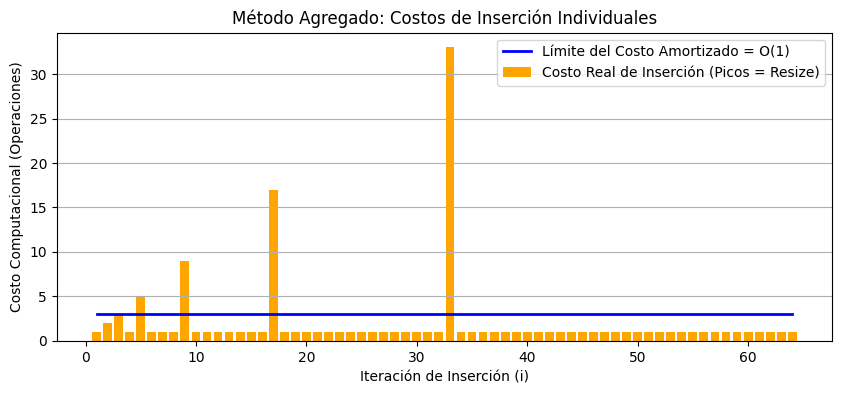

In [2]:
# Método Agregado: Gráfica del costo individual vs promedio amortizado
n = 64
individual_cost = []

capacity = 1
for i in range(1, n + 1):
    if i > capacity:
        cost_of_copy = i - 1
        capacity *= 2
    else:
        cost_of_copy = 0

    cost = 1 + cost_of_copy # Costo real de ESTA inserción particular
    individual_cost.append(cost)

amortized_cost = [3] * n # El costo amortizado demostrado matemáticamente es máximo 3

plt.figure(figsize=(10, 4))
plt.bar(range(1, n + 1), individual_cost, color='orange', label="Costo Real de Inserción (Picos = Resize)")
plt.plot(range(1, n + 1), amortized_cost, color='blue', linewidth=2, label="Límite del Costo Amortizado = O(1)")
plt.title("Método Agregado: Costos de Inserción Individuales")
plt.xlabel("Iteración de Inserción (i)")
plt.ylabel("Costo Computacional (Operaciones)")
plt.legend()
plt.grid(axis='y')
plt.show()


### 5.2 Método del Banquero (Banker's Method)
Imagínalo como un **préstamo amortizado o un ahorro preventivo**. Cobramos "extra" por las operaciones baratas y guardamos ese extra como *monedas* (tokens) en nuestra estructura de datos para pagar después por las operaciones caras.

*   Cobramos **3 monedas** por cada inserción (este es nuestro costo amortizado).
*   1 moneda paga el costo real de insertar el elemento en la posición actual.
*   Nos sobran **2 monedas**. Guardamos una en el nuevo elemento insertado, y guardamos la otra moneda sobre un elemento antiguo que se encuentra en la primera mitad del arreglo (los elementos $i - capacity/2$).

Cuando el arreglo se llena (su tamaño llega a $capacity$), significa que hemos guardado 2 monedas por cada elemento desde el último redimensionamiento. ¡Justo tenemos una moneda encima de CADA elemento del arreglo! Usamos esas monedas para pagar el costo de copiar todos los elementos al nuevo arreglo.
Como cobramos siempre 3 de manera constante, el costo amortizado es **$O(1)$**.


### 5.3 Método del Físico (Physicist's Method)
Definimos una **Función de Potencial** $\Phi(h)$ que mapea el estado de nuestra estructura de datos a un número entero.
Propiedades: $\Phi(h_0) = 0$ y $\Phi(h_t) \ge 0$.

El costo amortizado para la operación $t$ se define como:
$$ \text{Costo Amortizado} = c_t + \Phi(h_t) - \Phi(h_{t-1}) $$
(El costo real más el cambio de potencial).

Elegimos $\Phi$ para que la energía crezca en operaciones baratas y se descargue (caiga) fuertemente en las operaciones caras.
Para arreglos dinámicos, escogemos:
$$ \Phi(h) = 2 \times size - capacity $$

**Caso 1: Inserción sin redimensionamiento (barata)**
*   $c_i = 1$
*   $\Phi(h_i) - \Phi(h_{i-1}) = (2 \times size_i - cap_i) - (2 \times size_{i-1} - cap_{i-1})$.
*   Como $cap$ no cambia, y el tamaño creció en 1, el diferencial es $2$.
*   Costo Amortizado = $1 + 2 = 3$.

**Caso 2: Inserción con redimensionamiento (cara)**
Supongamos que $size_{i-1} = cap_{i-1} = k$. Por tanto el $size_i = k+1$.
*   $c_i = k + 1$ (el $k$ del copiado más el 1 de la inserción).
*   $\Phi(h_{i-1}) = 2(k) - k = k$.
*   $\Phi(h_i) = 2(k+1) - 2k = 2$.
*   Costo Amortizado = $c_i + \Phi(h_i) - \Phi(h_{i-1}) = (k+1) + 2 - k = 3$.

En ambos casos matemáticamente el costo amortizado es exactamente **3**. Por lo tanto, ¡la inserción toma tiempo **$O(1)$ amortizado**!


<>:17: SyntaxWarning: invalid escape sequence '\P'
<>:20: SyntaxWarning: invalid escape sequence '\P'
<>:17: SyntaxWarning: invalid escape sequence '\P'
<>:20: SyntaxWarning: invalid escape sequence '\P'
/tmp/ipykernel_2243/2111075323.py:17: SyntaxWarning: invalid escape sequence '\P'
  plt.plot(range(1, n + 1), potentials, color='purple', marker='o', linewidth=2, label="Energía Potencial $\Phi(h)$")
/tmp/ipykernel_2243/2111075323.py:20: SyntaxWarning: invalid escape sequence '\P'
  plt.ylabel("Energía Almacenada $\Phi$")


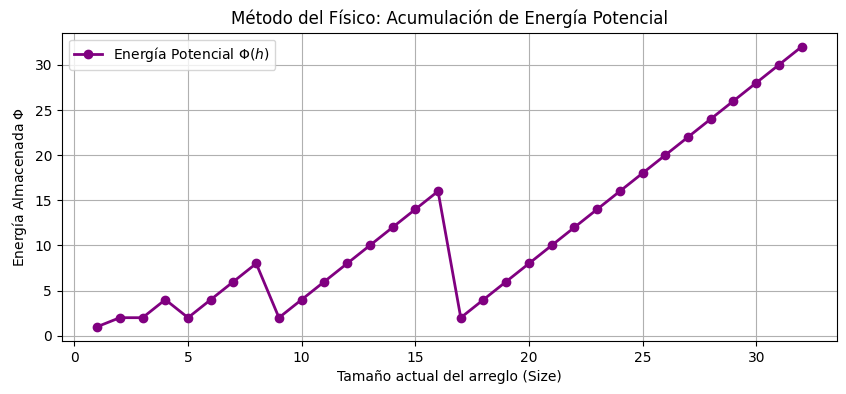

In [3]:
# Método del Físico: Energía Potencial
n = 32
potentials = []

capacity = 1
size = 0
for i in range(1, n + 1):
    size += 1
    if size > capacity:
        capacity *= 2

    # Ecuación del Físico: Phi = 2 * size - capacity
    phi = 2 * size - capacity
    potentials.append(phi)

plt.figure(figsize=(10, 4))
plt.plot(range(1, n + 1), potentials, color='purple', marker='o', linewidth=2, label="Energía Potencial $\Phi(h)$")
plt.title("Método del Físico: Acumulación de Energía Potencial")
plt.xlabel("Tamaño actual del arreglo (Size)")
plt.ylabel("Energía Almacenada $\Phi$")
plt.legend()
plt.grid(True)
plt.show()


## 6. Optimizaciones y Aplicaciones Avanzadas

### 6.1 Aplicación: Pilas (Stacks) y Corchetes Balanceados
En guías anteriores aprendimos a construir Pilas (`Stacks`). El motor interno ideal para una Pila es justamente un Arreglo Dinámico (en Java, es la base de la clase `Stack` y `ArrayDeque`). Al poder hacer `PushBack` (insertar) y sacar del final en $O(1)$ amortizado, el rendimiento es impecable.

**Problema Preparatorio:** En nuestra próxima actividad práctica construiremos el algoritmo de **Corchetes Balanceados** (`{[()]}`), donde usaremos un `DynamicArray` como Pila para procesar e ir eliminando pares de caracteres válidos en tiempo real.

### 6.2 Aplicación: Colas Circulares (Circular Queues)
Construir una Cola (`Queue`) sobre un arreglo tradicional es un infierno de rendimiento: al sacar un elemento del frente del arreglo (posición 0), tendríamos que empujar todos los demás a la izquierda, lo que cuesta $O(n)$.

¿La solución? Una **Cola Circular**. Utilizando un Arreglo Dinámico, manejamos dos punteros (`frente` y `final`). Cuando el `final` llega a la capacidad máxima del arreglo, en vez de obligar un redimensionamiento inmediatamente, utilizamos el operador Módulo (`%`) para hacer que el puntero "dé la vuelta" y aproveche los espacios vacíos que dejó el `frente`. Solo redimensionamos cuando genuinamente *todos* los espacios del círculo están llenos.

### 6.3 Shrinking: Recuperando Memoria Perdida
A lo largo de la guía hemos visto cómo crecer (duplicar) la capacidad para evitar ineficiencias de memoria, pero ¿qué sucede cuando borramos elementos? Si un arreglo tenía capacidad de un millón, y borramos todo dejándolo con tamaño `5`, la RAM sigue bloqueada inútilmente.

En la industria, los arreglos dinámicos no solo crecen, sino que **se encogen (Shrink)**. La regla de oro para encoger **NO** es reducir a la mitad cuando llega al 50%, ya que esto generaría un problema terrible de rendimiento si el usuario agrega y quita elementos constantemente en el borde. La regla ideal es:
> *Si el `size` cae por debajo del 25% (un cuarto de la capacidad total), entonces reducimos la capacidad a la mitad (50%).*

### 6.4 ¿Qué pasa "Bajo el capó"? (Garbage Collection vs Realloc)
Cuando nuestro arreglo interno "colapsa" por capacidad, copiamos todo al nuevo y "abandonamos" el viejo. Pero, ¿qué pasa físicamente en la memoria de la computadora?
*   **En Java/Python:** El lenguaje usa un sistema automático llamado *Garbage Collector* (Recolector de Basura). Al ver que el viejo arreglo ya no tiene ninguna variable que lo apunte, automáticamente reclama esa porción de memoria RAM y la libera.
*   **En C/C++:** Esta magia no existe. Debes usar manualmente una función de sistema como `realloc()`, la cual negocia directamente con el Sistema Operativo para intentar expandir el bloque actual de memoria sin copiar, o hacerlo bajo tu propio riesgo.


## 7. Batalla de Rendimiento: Arreglos Dinámicos vs. Listas Enlazadas

Dado que ambos son dinámicos (crecen según se necesita), ¿por qué casi todos los desarrolladores prefieren usar Arreglos Dinámicos (`ArrayList`) en lugar de Listas Enlazadas (`LinkedList`)? La respuesta radica en el *Hardware*.

| Característica | Arreglo Dinámico (ArrayList) | Lista Enlazada (LinkedList) |
| :--- | :--- | :--- |
| **Acceso Aleatorio `Get(i)`** | **Velocidad de la luz $O(1)$** | Lento $O(n)$ |
| **Localidad de Caché (Hardware)** | **Excelente.** Como están contiguos, la CPU carga bloques enteros a la L1 Caché a extrema velocidad. | **Pésimo.** Los Nodos están dispersos por toda la RAM, provocando "Cache Misses". |
| **Desperdicio de Memoria (RAM)** | Desperdicia espacio reservado (Capacity no utilizada), máximo el 50%. | **Pésimo.** Aunque no reserva extra, cada nodo gasta el doble de RAM guardando flechas (punteros). |
| **Insertar en Medio** | Lento $O(n)$ (Debe desplazar todos a la derecha) | **Rápido $O(1)$** (Solo si ya tienes el puntero exacto, sino $O(n)$ buscándolo) |

En resumen, los Arreglos Dinámicos ganan aplastantemente en aplicaciones modernas por su sinergia con la arquitectura de la memoria Caché de los procesadores actuales.


## 8. Ejercicios Prácticos

### Ejercicio 1: Estructura Básica con Shrinking (`DynamicArray`)
A partir de la plantilla propuesta, implementa tu propia versión de `ArrayList` que no solo crezca, sino que también tenga un método `RemoveLast()` que, si detecta que el arreglo está al 25% de capacidad, reduzca su capacidad interna a la mitad.


In [4]:
%%writefile DynamicArray.java
import java.util.Arrays;

public class DynamicArray {
    private int[] arr;
    private int size;
    private int capacity;

    // Constructor
    public DynamicArray(int initialCapacity) {
        if (initialCapacity <= 0) {
            initialCapacity = 1;
        }
        this.capacity = initialCapacity;
        this.arr = new int[capacity];
        this.size = 0;
    }

    // ADT: PushBack (Añadir al final)
    public void pushBack(int val) {
        if (size == capacity) {
            capacity = capacity * 2;
            int[] newArr = new int[capacity];
            for (int i = 0; i < size; i++) {
                newArr[i] = arr[i];
            }
            arr = newArr;
            System.out.println("-> [SISTEMA] Redimensionando el arreglo (GROW). Nueva capacidad: " + capacity);
        }
        arr[size] = val;
        size++;
    }

    // ADT: RemoveLast (Quitar del final y Shrink)
    public void removeLast() {
        if (size == 0) return;

        size--; // Lógica pura: ignoramos el último dato

        // ¡TU CÓDIGO AQUÍ!
        // Implementa la lógica para que si 'size' es menor o igual a (capacity / 4),
        // la 'capacity' se divida por 2 (con un mínimo de capacidad 1), y se copie a un nuevo arreglo.
        // if(size <= capacity / 4) { ... }
    }

    public void printStatus() {
        System.out.println("Size (Usado): " + size + " | Capacity (Total): " + capacity);
    }

    public static void main(String[] args) {
        DynamicArray da = new DynamicArray(2);

        // Creciendo
        for(int i = 1; i <= 9; i++){
            da.pushBack(i * 10);
        }
        da.printStatus(); // Capacity debería estar en 16, Size en 9

        System.out.println("--- Empezando a eliminar datos ---");
        // Decreciendo
        for(int i = 0; i < 6; i++){
            da.removeLast();
        }

        // Aquí deberías ver un mensaje de Shrink si lo implementaste correctamente!
        da.printStatus();
    }
}


Writing DynamicArray.java


In [5]:
!javac DynamicArray.java
!java DynamicArray


[0.025s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.025s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.001s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.001s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
-> [SISTEMA] Redimensionando el arreglo (GROW). Nueva capacidad: 4
-> [SISTEMA] Redimensionando el arreglo (GROW). Nueva capacidad: 8
-> [SISTEMA] Redimensionando el arreglo (GROW). Nueva capacidad: 16
Size (Usado): 9 | Capacity (Total): 16
--- Empezando a eliminar datos ---
Size (Usado): 3 | Capacity (Total): 16


## 9. Resumen
*   Es **obligatorio crecer utilizando multiplicación** (ej. `cap * 2`) y no suma constante, de lo contrario la estructura pasa a tener ineficiencia $O(n^2)$.
*   Añadir un elemento (`PushBack`) toma tiempo constante $O(1)$ amortizado.
*   Tres formas principales de hacer Análisis Amortizado: Agregado (sumatoria de costos), Banquero (Monedas y tokens), Físico (Energía potencial $\Phi$).
*   Se encogen los arreglos dinámicos (`Shrink`) al 50% de capacidad cuando el uso de memoria baja del 25%, evitando oscilaciones catastróficas de memoria.
*   Los Arreglos Dinámicos tienen muchísima mejor eficiencia a nivel de Hardware (Caché Hit) que las Listas Enlazadas en la abrumadora mayoría de casos de uso.


---
## 10. Bibliografía
- Streib, J. T. (2014). *Guide to Data Structures: A Concise Introduction Using Java*. Springer. (Capítulo sobre Dynamic Arrays and Amortized Analysis).